In [1]:
# --- COLAB CELL 1 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# 1. Automatic Data Retrieval using your RAW GitHub link
# This completely bypasses the need for manual file uploads
RAW_URL = "https://raw.githubusercontent.com/justnahid01/Decision-Tree-Comparison/main/dataset/DT_Dataset.csv"

try:
    df = pd.read_csv(RAW_URL)
    print("✅ Dataset loaded successfully directly from GitHub!")
    display(df.head(3))
except Exception as e:
    print("❌ Error loading dataset. Please check your GitHub link.")

✅ Dataset loaded successfully directly from GitHub!


,Age,Income,Years_Experience,Department,Approved
0,56.0,49927.145830,17.0,Marketing,1
1,46.0,44250.150406,9.0,Engineering,0
2,32.0,43062.097097,5.0,Sales,0


In [2]:
# --- COLAB CELL 2 ---
# Separate features (X) and target (y)
X = df.drop('Approved', axis=1)
y = df['Approved']

# A. Handle Missing Values (Imputation)
# Find columns with numbers and fill missing values with the median
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
imputer = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])

# B. Encode Categorical Features
# Find text columns (like Department) and convert them to numbers
cat_cols = X.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

# Scale the data (helps with plotting the decision boundary later)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into 70% Training and 30% Testing data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print("✅ Preprocessing Complete: Missing values handled and categories encoded.")

✅ Preprocessing Complete: Missing values handled and categories encoded.


In [3]:
# --- COLAB CELL 3 ---
# Define the hyperparameter grid we want to test
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20]
}

# --- 1. CART Implementation (Gini) ---
cart_base = DecisionTreeClassifier(criterion='gini', random_state=42)
cart_grid = GridSearchCV(cart_base, param_grid, cv=5, scoring='accuracy')
cart_grid.fit(X_train, y_train)
cart_best = cart_grid.best_estimator_ # Save the best tuned model

# --- 2. ID3 Implementation (Entropy) ---
id3_base = DecisionTreeClassifier(criterion='entropy', random_state=42)
id3_grid = GridSearchCV(id3_base, param_grid, cv=5, scoring='accuracy')
id3_grid.fit(X_train, y_train)
id3_best = id3_grid.best_estimator_ # Save the best tuned model

print(f"✅ CART Best Parameters: {cart_grid.best_params_}")
print(f"✅ ID3 Best Parameters: {id3_grid.best_params_}")

# Generate predictions for both models to use in visualizations
y_pred_cart = cart_best.predict(X_test)
y_prob_cart = cart_best.predict_proba(X_test)[:, 1]

y_pred_id3 = id3_best.predict(X_test)
y_prob_id3 = id3_best.predict_proba(X_test)[:, 1]

✅ CART Best Parameters: {'max_depth': 5, 'min_samples_split': 10}
✅ ID3 Best Parameters: {'max_depth': 3, 'min_samples_split': 2}


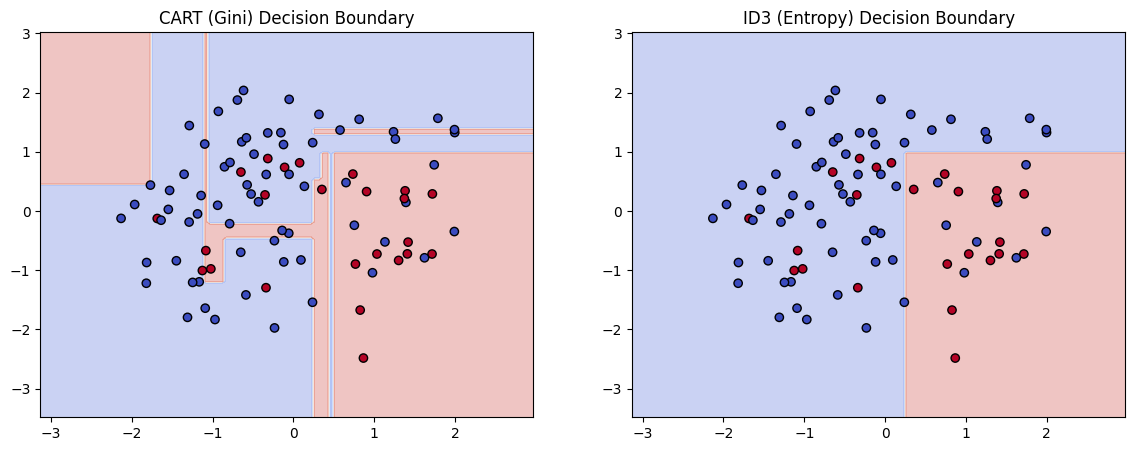

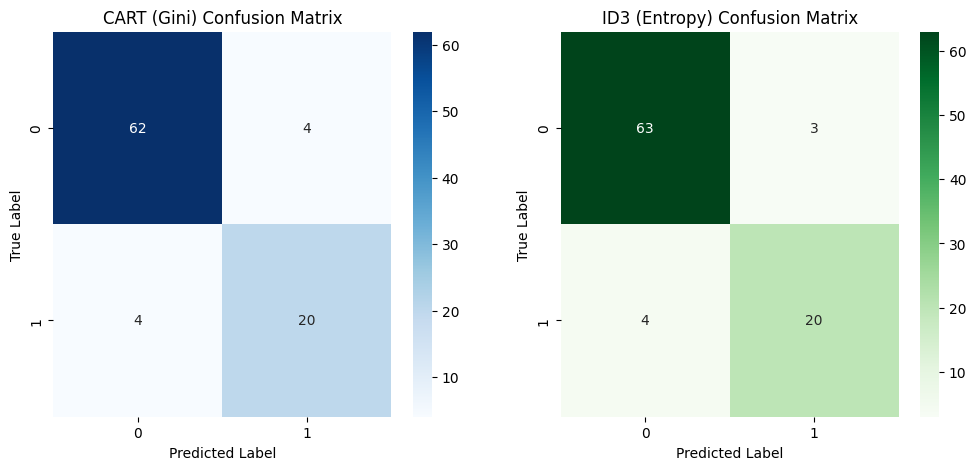

In [4]:
# --- COLAB CELL 4 ---
# VISUAL 1: Decision Boundary Plot (2x1 Matrix)
# We use PCA to reduce the 4 features down to 2 just for plotting the map
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train temp models for 2D visualization using our best params
cart_pca = DecisionTreeClassifier(criterion='gini', max_depth=cart_grid.best_params_['max_depth']).fit(X_train_pca, y_train)
id3_pca = DecisionTreeClassifier(criterion='entropy', max_depth=id3_grid.best_params_['max_depth']).fit(X_train_pca, y_train)

# Create grid for background colors
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))

Z_cart = cart_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_id3 = id3_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
axes1[0].contourf(xx, yy, Z_cart, alpha=0.3, cmap='coolwarm')
axes1[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolor='k', cmap='coolwarm')
axes1[0].set_title('CART (Gini) Decision Boundary')

axes1[1].contourf(xx, yy, Z_id3, alpha=0.3, cmap='coolwarm')
axes1[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolor='k', cmap='coolwarm')
axes1[1].set_title('ID3 (Entropy) Decision Boundary')
plt.show()

# VISUAL 2: Confusion Matrix Heatmap (2x1 Matrix)
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_cart), annot=True, fmt='d', cmap='Blues', ax=axes2[0])
axes2[0].set_title('CART (Gini) Confusion Matrix')
axes2[0].set_ylabel('True Label')
axes2[0].set_xlabel('Predicted Label')

sns.heatmap(confusion_matrix(y_test, y_pred_id3), annot=True, fmt='d', cmap='Greens', ax=axes2[1])
axes2[1].set_title('ID3 (Entropy) Confusion Matrix')
axes2[1].set_ylabel('True Label')
axes2[1].set_xlabel('Predicted Label')
plt.show()

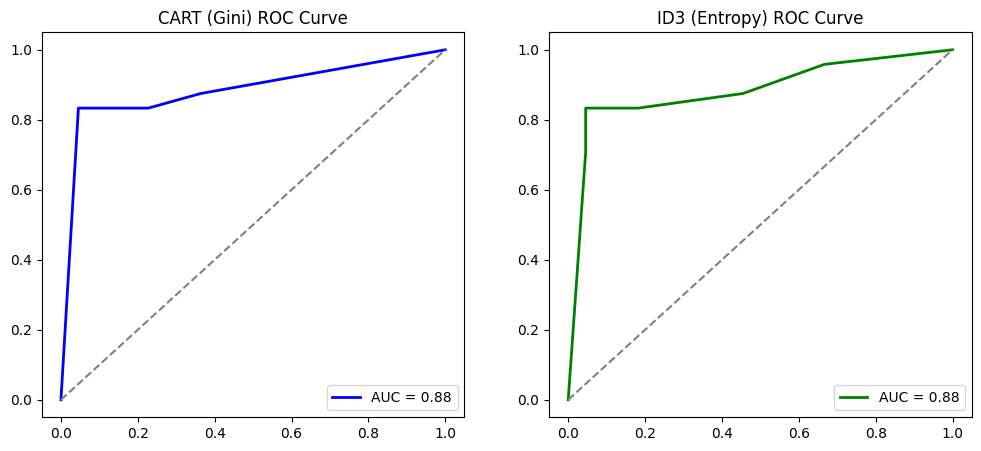

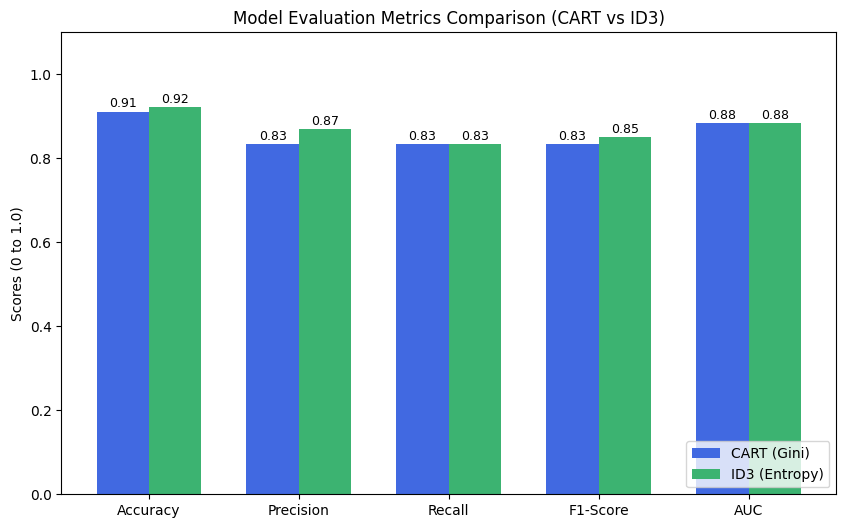

In [5]:
# --- COLAB CELL 5 ---
# VISUAL 3: ROC Curve Plot (2x1 Matrix)
fpr_cart, tpr_cart, _ = roc_curve(y_test, y_prob_cart)
fpr_id3, tpr_id3, _ = roc_curve(y_test, y_prob_id3)

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))
axes3[0].plot(fpr_cart, tpr_cart, color='blue', lw=2, label=f'AUC = {roc_auc_score(y_test, y_prob_cart):.2f}')
axes3[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes3[0].set_title('CART (Gini) ROC Curve')
axes3[0].legend(loc='lower right')

axes3[1].plot(fpr_id3, tpr_id3, color='green', lw=2, label=f'AUC = {roc_auc_score(y_test, y_prob_id3):.2f}')
axes3[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes3[1].set_title('ID3 (Entropy) ROC Curve')
axes3[1].legend(loc='lower right')
plt.show()

# VISUAL 4: Evaluation Metrics Bar Chart (Combined)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
cart_scores = [accuracy_score(y_test, y_pred_cart), precision_score(y_test, y_pred_cart),
               recall_score(y_test, y_pred_cart), f1_score(y_test, y_pred_cart), roc_auc_score(y_test, y_prob_cart)]
id3_scores = [accuracy_score(y_test, y_pred_id3), precision_score(y_test, y_pred_id3),
              recall_score(y_test, y_pred_id3), f1_score(y_test, y_pred_id3), roc_auc_score(y_test, y_prob_id3)]

x = np.arange(len(metrics))
width = 0.35

fig4, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, cart_scores, width, label='CART (Gini)', color='royalblue')
ax.bar(x + width/2, id3_scores, width, label='ID3 (Entropy)', color='mediumseagreen')

ax.set_ylabel('Scores (0 to 1.0)')
ax.set_title('Model Evaluation Metrics Comparison (CART vs ID3)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
plt.ylim(0, 1.1)

# Add exact numbers on top of the bars
for i, v in enumerate(cart_scores):
    ax.text(i - width/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
for i, v in enumerate(id3_scores):
    ax.text(i + width/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.show()

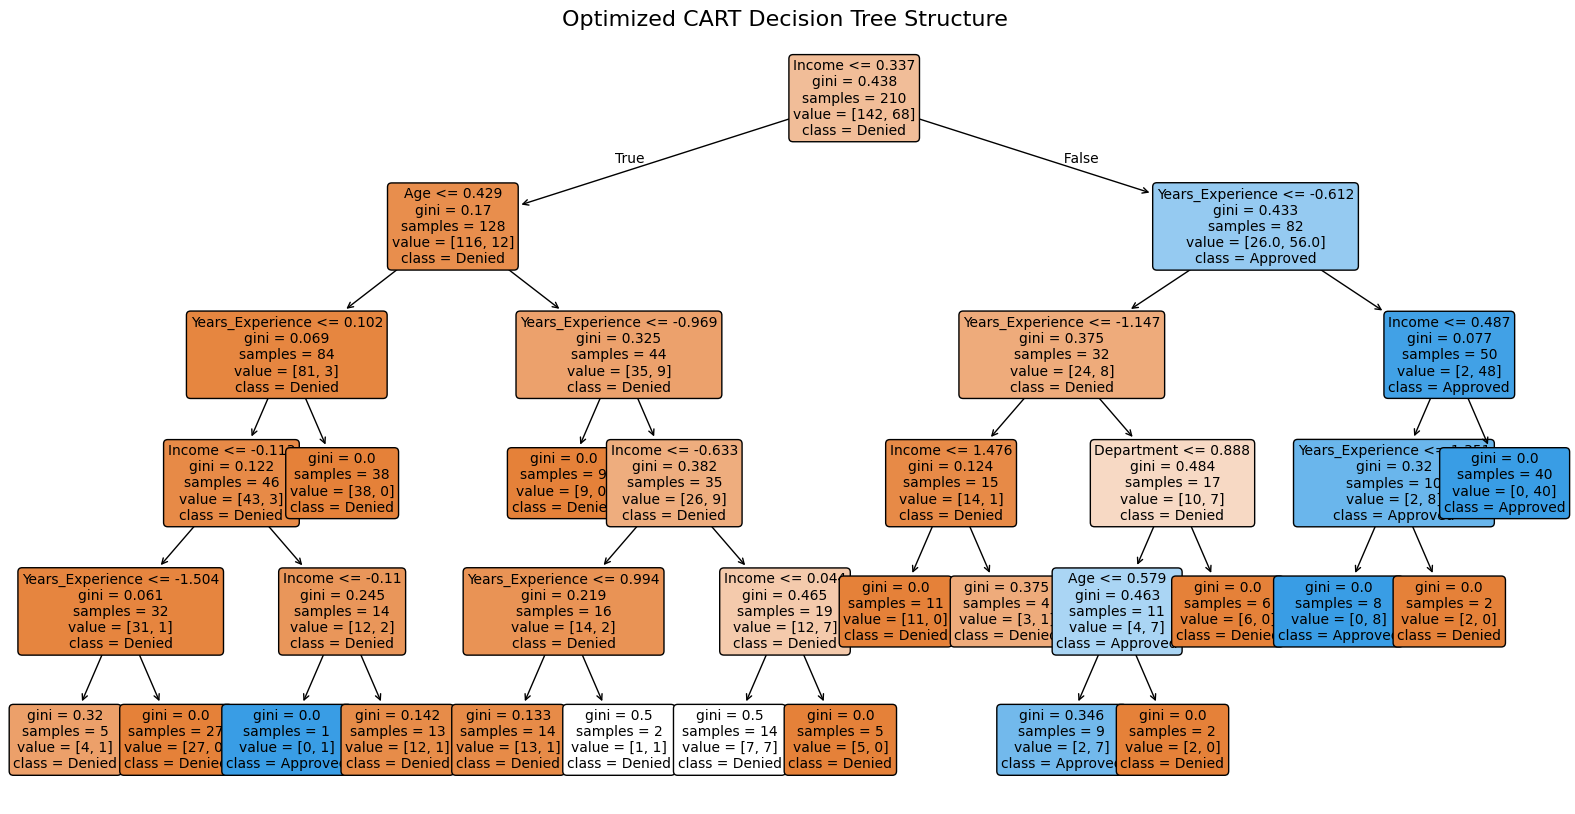

In [6]:
# --- COLAB CELL 6 ---
# VISUAL 5: DT Structure Visualization (Single Image)
plt.figure(figsize=(20, 10))
# We plot the fully tuned CART tree
plot_tree(cart_best, feature_names=X.columns, class_names=['Denied', 'Approved'], filled=True, rounded=True, fontsize=10)
plt.title("Optimized CART Decision Tree Structure", fontsize=16)
plt.show()